# NOTEBOOK 22: visualise hourly HVSR data


## Authors:
* Koen Van Noten ([@KoenVanNoten](https://github.com/KoenVanNoten))
* Thomas Lecocq ([@seismotom](https://github.com/ThomasLecocq))

## Introduction:
Three-component __seismic nodes__ are conquering the world these days as lightweight smart seismic sensors. This notebook provides a guideline how to handle seismic node data and perform H/V spectral ratio analysis of ambient noise (mHVSR of HVSRN) recorded with seismic nodes. We'll show you some methods:
* how to perform mHVSR using hvsrpy
* how to do the same exercise automatically 
* and we'll open the discussion towards an interpretation of the results. 

## Citation

The essential codes to analyse the output data in this notebook are based on the following paper:
> Van Noten, K., Lecocq, T., Goffin, C., Meyvis, B., Molron, J., Debacker, T.N. & Devleeschouwer, X. 2022. Brussels’ 
> bedrock paleorelief from borehole-controlled powerlaws linking polarised H/V resonance frequencies and sediment 
> thickness. _Journal of Seismology_ 26, 35-55. 
> https://doi.org/10.1007/s10950-021-10039-8 

> https://publi2-as.oma.be/record/5626/files/2022_VanNotenetal_HVSR_Powerlaw_Brussels.pdf 

The codes results from:
> Van Noten, K, Lecocq, Buddha Power, B. (2020). HVSR to Virtual Borehole (1.0). Zenodo.
> https://doi.org/10.5281/zenodo.4276310

In [1]:
import hvsrpy
import obspy
import pathlib
import time
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import UTCDateTime, read, Stream
from HVSR_minionology import *

# use ipython notebook in a wider screen
from IPython.display import display, HTML
display(HTML("<style>.jp-Notebook{max-width:100%!important}.container{width:95%!important}#notebook-container{width:95%!important}</style>"))

### DATA and OUTPUT
As seen in previous notebooks, data comes from seismic data gathered from the Grenzgletscher, Switserland, in the Monta Rosa Massif. Data is property of Joachim Wasserman (LMU).  

In [2]:
## add you data path
DATA_PATH = '/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/'
# Give HVSR output path
output_folder = os.path.join(DATA_PATH, 'Analysed') 

## Is the average HVSR of one day sufficient to understand what's happening on a glacier?
No, would be better to have the HVSR evolution with time. Let's use Obspy to split a day pattern in hourly data, compute the HVSR and then evaluate the HVSR variability with time.

### While the other notebook is still running, let's visualise what we already got
First grab all the .hv data files computed for each hour

In [3]:
### Settings
network = 'XG'
station = 'BB01' # select station to plot
#station = None # or grab the data of all stations
Project = 'Grenzgletscher'

# Select the time zone. All sensor data is in UTC. Any HVSR data will be converted to local time zone
time_zone = 'Europe/Zurich'

# First do a freq_lim = False to grab the entire range. Go the next cell and plot the data
# Then come back here, and zoom in into the frequency of interest with freq_lim = True , and give the min and max
freq_lim = True
ylim_min = 0.8  # Hz
ylim_max = 5 # Hz

####### This function will now grab all HVSR data for each hour and store it in a database
grab_continuous_HV(output_folder, station, Project, time_zone, freq_lim, ylim_min = ylim_min , ylim_max = ylim_max, temperature = False)

Found 1 subfolders
Processing only: BB01
HV files for node BB01 exported in /Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/Analysed/BB01_HVSR_all_20240319-20240322.csv
Mean HVSR curve for node BB01 stored in /Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/Analysed/BB01_HVSR_mean.hv
Job done in 0.14 s
##################################################


### Now let's plot the HVSR variability with time
You will need to work a bit to get the right zoom level, focus on the right peak, etc


Processing only files containing: BB01
Processing: /Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/Analysed/BB01_HVSR_all_20240319-20240322.csv
reading HV files done 0.15 s
no temperature data
plotting HVSR - time graph done 0.16 s
f0 = 0.285 ± 0.000 Hz
calculating mean HVSR done 0.17 s
saving the HVSR figure done 1.21 s


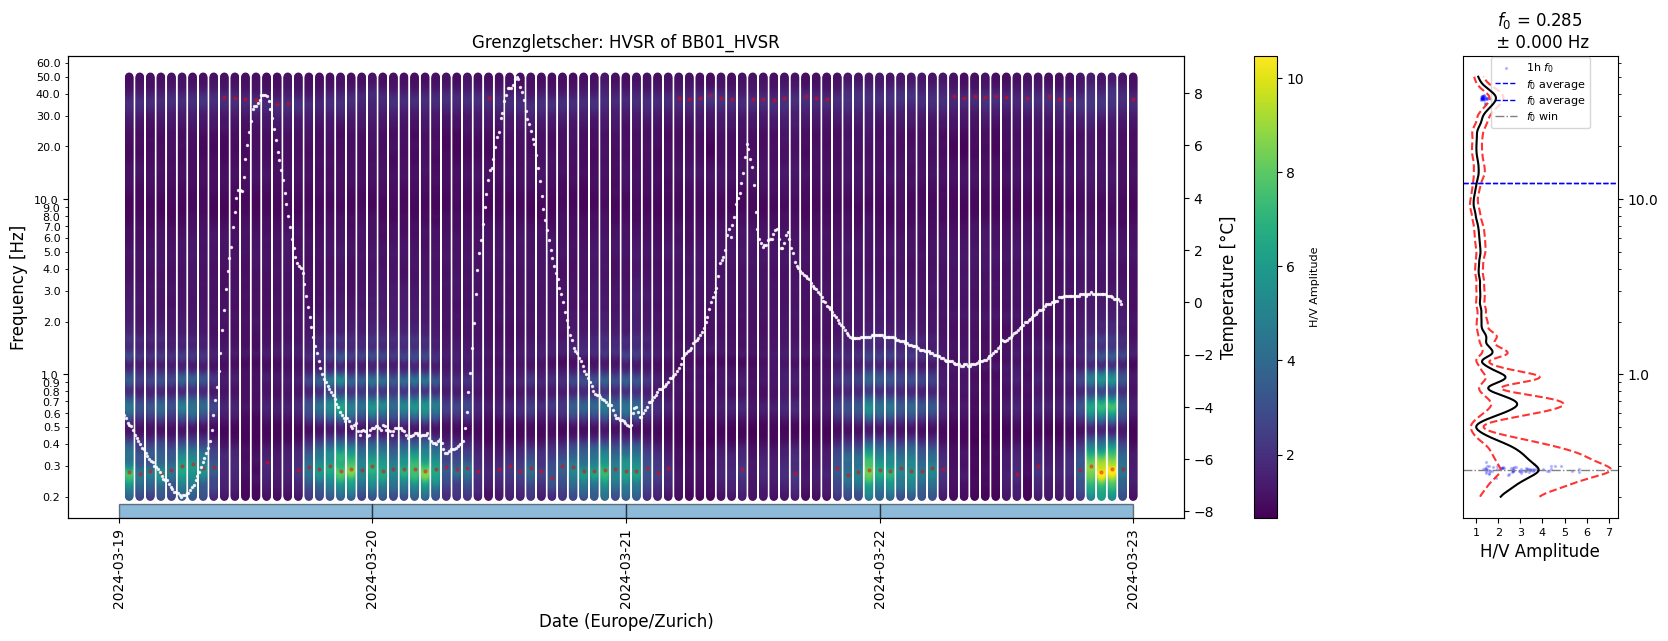

******************


In [4]:
## Station details
network = 'XG'
station = 'BB01'
#station = None 

Project = 'Grenzgletscher'
time_zone = 'Europe/Zurich'

temperature = True
temperature_file = 'Grenzgletscher_temperatures_lower.csv' # for the lower array
#temperature_file = 'Grenzgletscher_temperatures_upper.csv' # for the upper array

# which f0 to plot? numerical mean ('f0_win') or mean curve ('f0_avg')
f0_to_plot = 'f0_avg'

# Do you want to plot all dates ? 
auto_date = False
# If date_auto = False, then  plot only between selected dates. Format %YYYY-MM-DD hh:00:00 
start_date = '2024-03-19 00:00:00'
end_date = '2024-03-23 00:00:00'

# Want to plot local or UTC time?
time = 'Local_Time'
#time = 'UTC'
time_zone = 'Europe/Zurich'

# want to zoom on the certain frequency and amplitude range?
zoom = False
#### frequency limit
ylim_min , ylim_max = 0.2, 50

### amplitude limits
auto_amplitude = True
xlim_min, xlim_max = 0, 2.5

## Want the amplitudes in logscale ?
log_xscale = False

# the figure will be saved, don't plot it as well (slows down the process)
plot = True

### for volcano stuuf
VHSR = False

# thickness of the HV line
HV_line_thickness = 25

#########################################
plot_continuous_HV(Project, DATA_PATH, station, auto_date, start_date, end_date, time, time_zone, f0_to_plot=f0_to_plot, temperature = temperature, 
                   temperature_file = temperature_file, zoom = zoom, 
                   ylim_min = ylim_min, ylim_max = ylim_max, auto_amplitude = auto_amplitude, xlim_min = xlim_min, 
                   xlim_max = xlim_max, log_xscale = log_xscale, plot = plot , VHSR = VHSR, HV_line_thickness = HV_line_thickness)

### Now you can Virtual Borehole again on the mean HVSR of each station

/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/Analysed/BB01_HVSR_mean.hv
A0: 3.83 fmax:  0.28
1.265 0.285 0.0 3.829 96.0 2514.0 0.285 0.285
Z:  2549.34
bedrock at 2233.1  m (range:  2233.1 m,  2233.1 m)


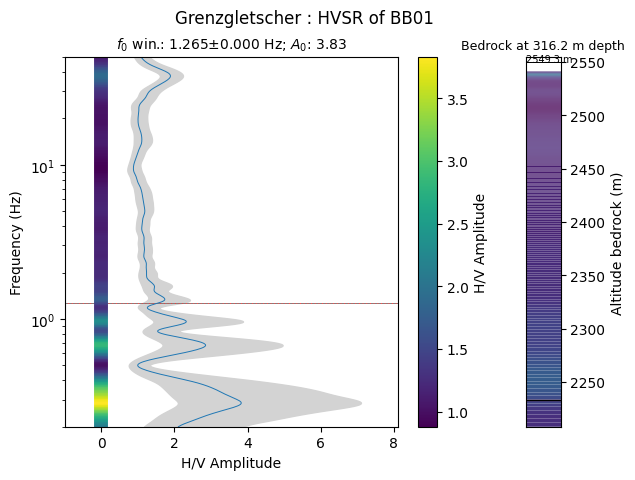

In [5]:
station = 'BB01'

### cryseismology
Project = 'Grenzgletscher'
Z = 2549.345  #surface height fo BB01

ID = station

# Choose if the amplitude on the frequency-amplitude plot needs to be selected automatically or manually
auto_amplitude = True
manual_amplitude = 20

# Choose between which frequencies you want to plot. Default = between 0.5 Hz and 50 Hz, or overwrite with [0.2, 100]
freq = [ylim_min, ylim_max]

## f0 needs to be converted to depth by: 

## 1. by using a Powerlaw relation between resonance frequency and depth according to the formula: depth = a * power(f0, b)
## a & b values of the Regional powerlaw relation (R') of Van Noten et al. 2022. (applicable for Brussels)
#depth_conversion = 'powerlaw'
a_pw = 88.631     # a value
b_pw = -1.683    # b value

## or by using a fixed velocity
depth_conversion = 'Vs'
Vs = 380 # m/s #Brussels subsurface
Vs = 1600 # m/s #Blue ice velocity

#virtual borehole
distance_above_surface = 5
distance_below_bedrock = 25 

###################################################################

HV_file = os.path.join(output_folder, '%s_HVSR_mean.hv')%station
print(HV_file)
if depth_conversion == 'powerlaw':
    HV_to_virtual_borehole(HV_file, ID, Z, 'f0_avg', Project, distance_below_bedrock, distance_above_surface, depth_conversion, 
                           a_pw = a_pw, b_pw=b_pw, auto_amplitude=auto_amplitude, manual_amplitude=manual_amplitude, freq = freq)
if depth_conversion == 'Vs':
    HV_to_virtual_borehole(HV_file, ID, Z, 'f0_avg', Project, distance_below_bedrock, distance_above_surface, depth_conversion, 
                           Vs=Vs, auto_amplitude=auto_amplitude, manual_amplitude=manual_amplitude, freq = freq)
#save it by node name
savefile = os.path.join(DATA_PATH, 'Analysed', '%s_Virtual_Borehole.png'%ID)
plt.savefig(savefile, format= 'png', dpi = 300)